!pip install latexify-py

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import matplotlib.patches as mpatches
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

try:
    from latexify import *
except ImportError:
    def latexify(*args, **kwargs): pass
    def format_axes(*args, **kwargs): pass

In [2]:
from sklearn.datasets import load_iris

In [3]:
from sklearn.datasets import load_iris
d = load_iris()
X = d['data'][:, :2]
y = d['target']
species = ['I. setosa', 'I. versicolor', 'I. virginica']

In [4]:
d['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Text(0, 0.5, 'sepal width (cm)')

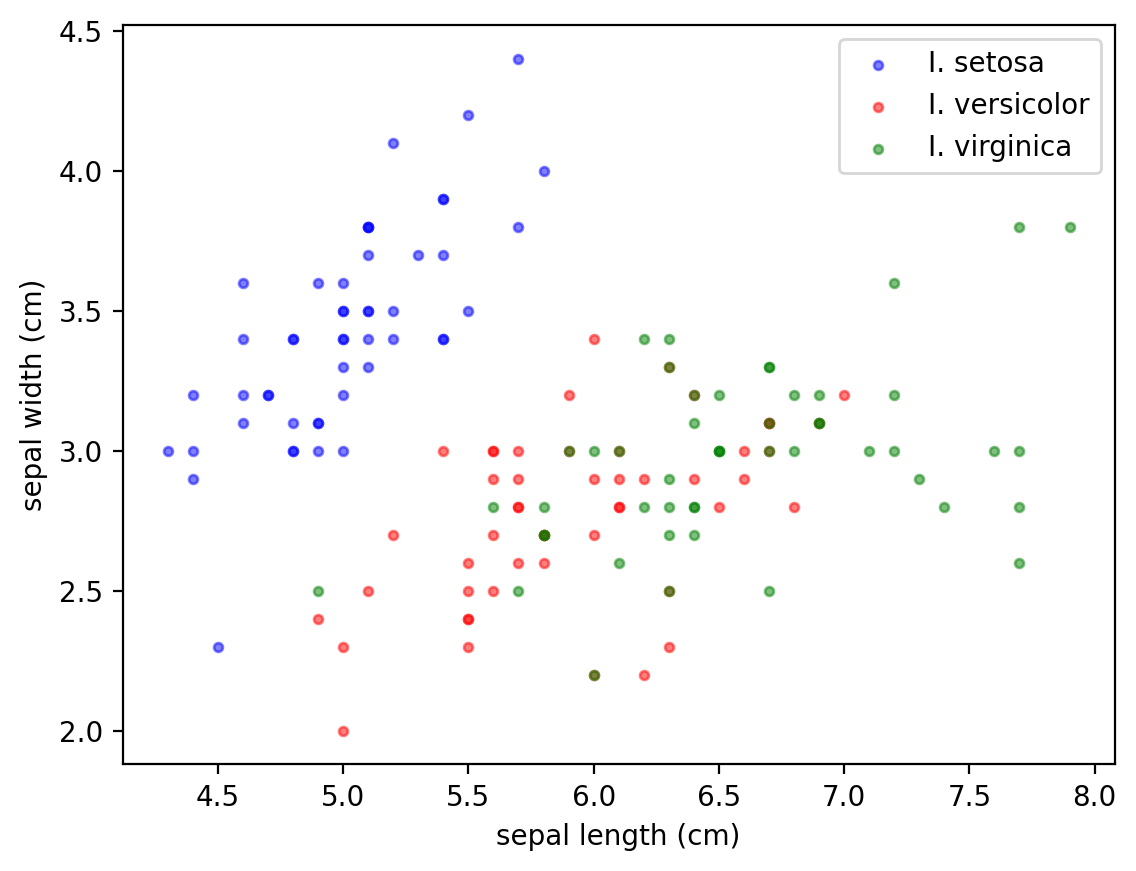

In [5]:
latexify()
colours = ['blue', 'red', 'green']
species = ['I. setosa', 'I. versicolor', 'I. virginica']
for i in range(0, 3):
    df_ = X[y == i]
    plt.scatter(
        df_[:, 0],
        df_[:, 1],
        color=colours[i],
        alpha=0.5,
        label=species[i] ,
        s=10
    )
format_axes(plt.gca())
plt.legend()
plt.xlabel(d['feature_names'][0])
plt.ylabel(d['feature_names'][1])


# plt.savefig("../figures/logistic-regression/logisitic-iris.pdf", bbox_inches="tight", transparent=True)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Implementing L1 and L2 regularization using the 'elasticnet' penalty.
# Note: 'saga' solver is required for elasticnet.
l1_ratio = 0.5  # 0.5 means equal weight to L1 and L2
clf = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=l1_ratio, C=1.0, max_iter=10000)
clf.fit(X, y)

In [7]:
clf.coef_

NameError: name 'clf' is not defined

In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))





Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.4)
plt.gca().set_aspect('equal')
#plt.scatter(X[:, 0], X[:, 1], c=y)
latexify()
for i in range(0, 3):
    df_ = X[y == i]
    plt.scatter(
        df_[:, 0],
        df_[:, 1],
        color=colours[i],
        alpha=0.5,
        label=species[i],
        s=10
    )
format_axes(plt.gca())
plt.legend()
plt.xlabel(d['feature_names'][0])
plt.ylabel(d['feature_names'][1])
# plt.savefig("../figures/logistic-regression/logisitic-iris-prediction.pdf", bbox_inches="tight", transparent=True)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the training data
y_pred = clf.predict(X)

# Calculate metrics
print("Classification Report:")
print(classification_report(y, y_pred, target_names=species))

# Generate and plot confusion matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()